# Modèle génératif 

## Import

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import urllib.request
import gzip
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt 
import torch.optim as optim
import torch.nn.functional as F

## Denoiser 

In [4]:
class BF_CNN(nn.Module): ## Modèle cité par les auteurs 

    def __init__(self, depth=20, n_channels=64, image_channels=1):
        super(BF_CNN, self).__init__()
        kernel_size = 3
        padding = 1
        layers = []
        
        
        layers.append(nn.Conv2d(image_channels, n_channels, kernel_size, padding=padding, bias=False))
        layers.append(nn.ReLU(inplace=True))
        
        for _ in range(depth - 2):
            layers.append(nn.Conv2d(n_channels, n_channels, kernel_size, padding=padding, bias=False))
            
            bn = nn.BatchNorm2d(n_channels, affine=True) # enlever les biais 
            bn.register_parameter('bias', None) 
            layers.append(bn)
            
            layers.append(nn.ReLU(inplace=True))
            
        layers.append(nn.Conv2d(n_channels, image_channels, kernel_size, padding=padding, bias=False))
        
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x):
        noise = self.dncnn(x)
        return x - noise


## Dataset 

utilisation de Mnist

In [5]:
def download_mnist():

    base_url = "http://yann.lecun.com/exdb/mnist/"
    files = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz"]
    os.makedirs('./data', exist_ok=True)


    for f in files:
        if not os.path.exists(f"./data/{f}"):

            print(f"Téléchargement de {f}...")
            from sklearn.datasets import fetch_openml
            mnist = fetch_openml('mnist_784', version=1, as_frame=False)
            X = mnist.data.reshape(-1, 1, 28, 28) / 255.0
            return torch.from_numpy(X).float()

mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X = mnist.data.reshape(-1, 1, 28, 28).astype(np.float32) / 255.0
train_tensor = torch.from_numpy(X)

# On crée notre propre DataLoader
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)


64


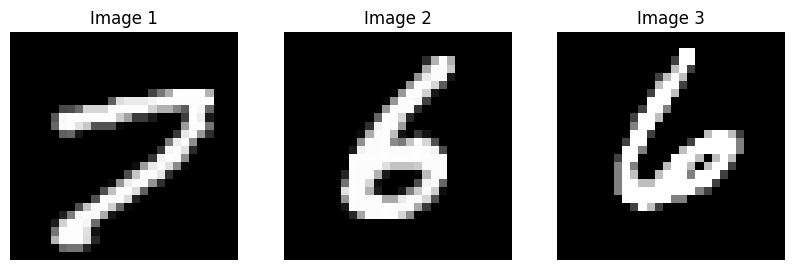

In [495]:
data_iter = iter(train_loader)
batch = next(data_iter)


images = batch[0] 
print(len(images))

plt.figure(figsize=(10, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    img = images[i].squeeze().numpy() 
    plt.imshow(img, cmap='gray')
    plt.title(f"Image {i+1}")
    plt.axis('off')

plt.show()


## entrainement CNN

In [417]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = BF_CNN(depth=12, n_channels=32).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()


# training 
def train_adam_clean(model, loader, epochs=10):
    model.train()
    
    for epoch in range(epochs):
        epoch_loss = 0
        for i, batch in enumerate(loader):
            images = batch[0].to(device)
            
            # Bruitage
            sigma = torch.rand(1, device=device) * 0.4
            noise = torch.randn_like(images) * sigma
            noisy_images = images + noise
            
            #forward
            optimizer.zero_grad()
            output = model(noisy_images)
            loss = criterion(output, images)
            
            #backward 
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs} | Loss moyenne: {epoch_loss / len(loader):.5f}")
        

train_adam_clean(model, train_loader, epochs=30)

Epoch 1/30 | Loss moyenne: 0.00899
Epoch 2/30 | Loss moyenne: 0.00432
Epoch 3/30 | Loss moyenne: 0.00404
Epoch 4/30 | Loss moyenne: 0.00380
Epoch 5/30 | Loss moyenne: 0.00361
Epoch 6/30 | Loss moyenne: 0.00355
Epoch 7/30 | Loss moyenne: 0.00340
Epoch 8/30 | Loss moyenne: 0.00326
Epoch 9/30 | Loss moyenne: 0.00314
Epoch 10/30 | Loss moyenne: 0.00315
Epoch 11/30 | Loss moyenne: 0.00323
Epoch 12/30 | Loss moyenne: 0.00312
Epoch 13/30 | Loss moyenne: 0.00296
Epoch 14/30 | Loss moyenne: 0.00306
Epoch 15/30 | Loss moyenne: 0.00297
Epoch 16/30 | Loss moyenne: 0.00296
Epoch 17/30 | Loss moyenne: 0.00281
Epoch 18/30 | Loss moyenne: 0.00294
Epoch 19/30 | Loss moyenne: 0.00286
Epoch 20/30 | Loss moyenne: 0.00278
Epoch 21/30 | Loss moyenne: 0.00287
Epoch 22/30 | Loss moyenne: 0.00280
Epoch 23/30 | Loss moyenne: 0.00291
Epoch 24/30 | Loss moyenne: 0.00281
Epoch 25/30 | Loss moyenne: 0.00274
Epoch 26/30 | Loss moyenne: 0.00280
Epoch 27/30 | Loss moyenne: 0.00276
Epoch 28/30 | Loss moyenne: 0.00273
E

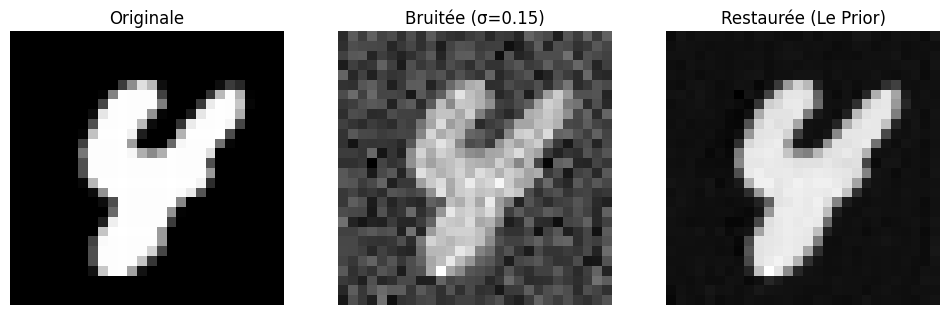

In [398]:
def test_denoiser(model, loader):
    model.eval() 
    
    batch = next(iter(loader))
    img_propre = batch[0][0:1].to(device) 
    
    sigma = 0.15
    bruit = torch.randn_like(img_propre) * sigma
    img_bruitee = img_propre + bruit
    
    with torch.no_grad():
        img_restauree = model(img_bruitee)
    
    imgs = [img_propre, img_bruitee, img_restauree]
    titles = ['Originale', f'Bruitée (σ={sigma})', 'Restaurée (Le Prior)']
    
    plt.figure(figsize=(12, 4))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(imgs[i].cpu().squeeze(), cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Lancement du test
test_denoiser(model, train_loader)

On voit que le CNN arrive globalement a bien débruité notre image 

## Résolution de problème linéaires 

Entre chaque problème qui sont résolus en dessous, il suffit de changer globalement la matrice M, l'algorithme restant le même (et sans doute reparamétriser mes hyperparamètres $h, \beta , \gamma$)

### Inpainting

/var/folders/vm/951zcnvn12z0rcgdyj5svs0c0000gn/T/ipykernel_3567/3914237579.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))


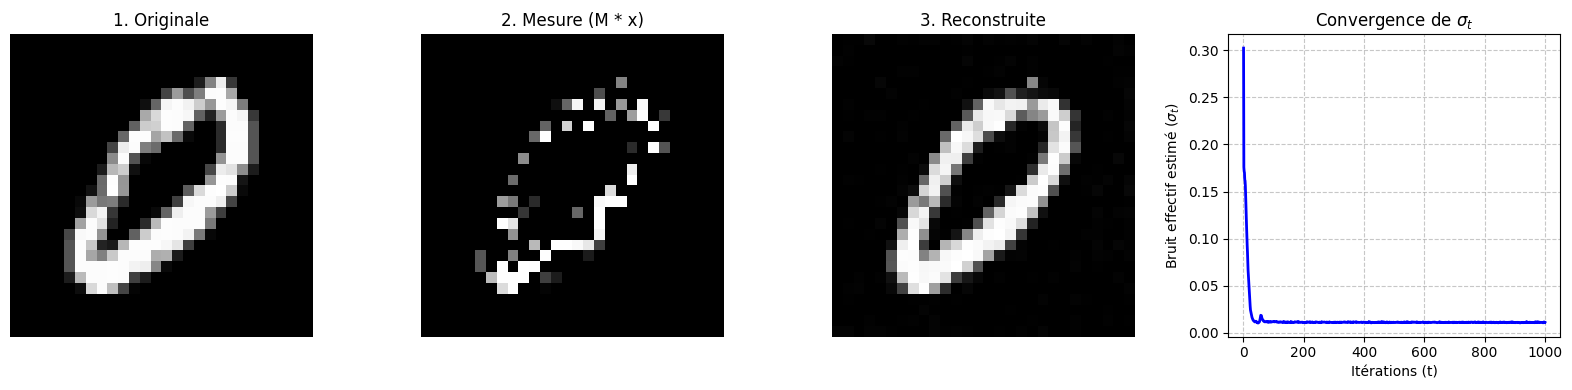

In [399]:
def inpainting_experiment_algo2(model, loader, num_iter=1000):
    '''Fait de l'inpainting en respectant strictement l'Algorithme 2 du papier, avec suivi de sigma'''

    model.eval() 
    
    batch = next(iter(loader))
    x_orig = batch[0][0:1].to(device) 
    
    # Masque (Exp 1 : Mettre un carré noir au milieu)
    mask = torch.ones_like(x_orig)
    #mask[:, :, 10:20, 10:20] = 0 

    #exp 2 (supprime aléatoirement)
    mask = (torch.rand_like(x_orig) > 0.6).float()
    
    x_mesure = x_orig * mask 
    
    h0 = 0.05 
    beta = 0.1 
    N = x_orig.numel() 
    
    y = x_mesure + torch.randn_like(x_orig) * 0.5 * (1 - mask)
    
    sigma_history = []
    
    for t in range(1, num_iter + 1):
        h_t = (h0 * t) / (1 + h0 * (t - 1))
        
        with torch.no_grad():
            x_hat = model(y)
        f_y = x_hat - y 
        
        d_t = (1 - mask) * f_y + mask * (x_mesure - y)
        
        # Estimation de sigma_t^2 (norm_sq)
        norm_sq = torch.sum(d_t**2) / N
        
        sigma_t = torch.sqrt(norm_sq).item()
        sigma_history.append(sigma_t)
        
        variance_factor = max((1 - beta * h_t)**2 - (1 - h_t)**2, 0.0) 
        gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))
        
        noise = torch.randn_like(y) * gamma_t
        y = y + h_t * d_t + noise
        y = torch.clamp(y, 0, 1)

    plt.figure(figsize=(16, 4))
    
    plt.subplot(1, 4, 1)
    plt.imshow(x_orig.cpu().squeeze(), cmap='gray')
    plt.title("1. Originale")
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(x_mesure.cpu().squeeze(), cmap='gray')
    plt.title("2. Mesure (M * x)")
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    img_finale = torch.clamp(y, 0, 1).cpu().squeeze()
    plt.imshow(img_finale, cmap='gray')
    plt.title("3. Reconstruite")
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.plot(range(1, num_iter + 1), sigma_history, color='blue', linewidth=2)
    plt.title(r"Convergence de $\sigma_t$")
    plt.xlabel("Itérations (t)")
    plt.ylabel(r"Bruit effectif estimé ($\sigma_t$)")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Lancer l'expérience
inpainting_experiment_algo2(model, train_loader, num_iter=1000)

J'ai fait deux epériences (il suffit de changer deux lignes dans ma fonction au dessus). Je pense qu'il y a un problème majeur sur ce que je fais au dessus, cela vient principalement du CNN qui ait sans doute pas assez entrainé. 

La reconstruction est globalement bonne quand on enlève un carré de notre image et on voit qu'on arrive à quand même visualiser la forme de notre image. Cependant, parfois il va imaginer des formes complètement imaginaire

Quand on supprime des pixels aléatoires, la reconstruction est plutôt bonne sauf quand on comment à supprimer au delà d'un certain seuil où le manque d'entrainement se fait ressentir. 

### Ajout de Flou

In [65]:
def get_blur_operator(kernel_size=5, sigma=1.5):
    """Crée une convolution de flou gaussien pour M"""
    
    coords = torch.arange(kernel_size).to(device) - (kernel_size - 1) / 2
    g = torch.exp(-(coords**2) / (2 * sigma**2))
    g = g / g.sum() # Normalisation

    g2d = g.view(-1, 1) * g.view(1, -1)
    
    kernel = g2d.view(1, 1, kernel_size, kernel_size)
    
    kernel.requires_grad = False
    return kernel

kernel_blur = get_blur_operator(kernel_size=7, sigma=2.0)

# Fonction pour appliquer M : M(x) = x_flouté
def blur(x):
    # padding='same' pour garder la taille de l'image (28x28)
    return F.conv2d(x, kernel_blur, padding='same')

# Fonction pour appliquer M^T (la transposée) : M_T(x)
def blur_transpose(x):

    return F.conv2d(x, kernel_blur, padding='same')


/var/folders/vm/951zcnvn12z0rcgdyj5svs0c0000gn/T/ipykernel_3567/2901716805.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))


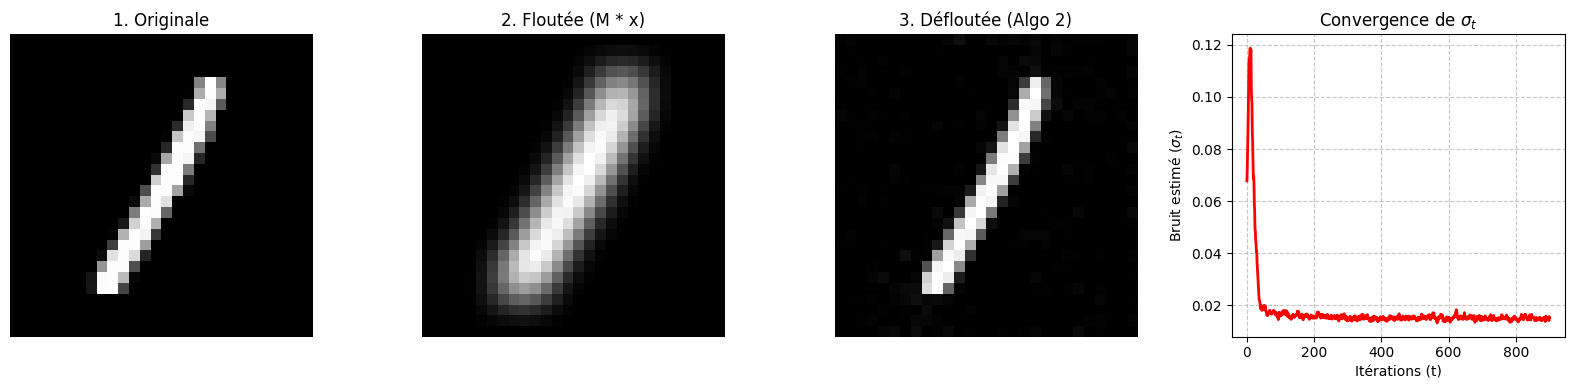

In [405]:
def deblur_experiment_algo2(model, loader, num_iter=900):

    model.eval() # mode évaluation
    
    batch = next(iter(loader))
    x_orig = batch[0][0:1].to(device) # Image propre
    
    # Création de l'observation
    y_obs = blur(x_orig)
    
    # Paramètres de l'Algorithme 2
    h0 = 0.05
    beta = 0.01
    N = x_orig.numel()
    
    # Initialisation
    y = y_obs.clone()
    y.requires_grad = False
    
    sigma_history = []
    
    for t in range(1, num_iter + 1):
        # h
        h_t = (h0 * t) / (1 + h0 * (t - 1))
        
        # grad
        with torch.no_grad():
            x_hat = model(y)
        f_y = x_hat - y 
        
        erreur = blur(y) - y_obs
        data_gradient = blur_transpose(erreur)
        
        d_t = f_y - 2.0 * data_gradient
        
        # bruit
        norm_sq = torch.sum(d_t**2) / N
        sigma_t = torch.sqrt(norm_sq).item()
        sigma_history.append(sigma_t)
        
        # amplitude
        variance_factor = max((1 - beta * h_t)**2 - (1 - h_t)**2, 0.0)
        gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))
        
        # Itération (injection de bruit et montée de gradient)
        noise = torch.randn_like(y) * gamma_t
        y = y + h_t * d_t + noise
        y = torch.clamp(y, 0, 1)

    # ==========================
    # AFFICHAGE DES RÉSULTATS
    # ==========================
    plt.figure(figsize=(16, 4))
    
    plt.subplot(1, 4, 1)
    plt.imshow(x_orig.cpu().squeeze(), cmap='gray')
    plt.title("1. Originale")
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(y_obs.cpu().squeeze(), cmap='gray')
    plt.title("2. Floutée (M * x)")
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    img_finale = torch.clamp(y, 0, 1).cpu().squeeze().detach()
    plt.imshow(img_finale, cmap='gray')
    plt.title("3. Défloutée (Algo 2)")
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.plot(range(1, num_iter + 1), sigma_history, color='red', linewidth=2)
    plt.title(r"Convergence de $\sigma_t$")
    plt.xlabel("Itérations (t)")
    plt.ylabel(r"Bruit estimé ($\sigma_t$)")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Lancer l'expérience
deblur_experiment_algo2(model, train_loader, num_iter=900)

L'opération de défloutage est plutôt bonne et on retrouve assez bien l'image originale. 

### Super-Résolution 

In [71]:
facteur = 2 # On divise la résolution par 2 (image 4 fois plus petite en surface)

def downsample(x):
    # Matrice M : On moyenne des blocs de 2x2 pixels
    return F.avg_pool2d(x, kernel_size=facteur)

def upsample(x):
    # Matrice M^T : Transposée de l'opération de moyenne
    x_up = F.interpolate(x, scale_factor=facteur, mode='nearest')
    return x_up / (facteur ** 2)

/var/folders/vm/951zcnvn12z0rcgdyj5svs0c0000gn/T/ipykernel_3567/2069071334.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))


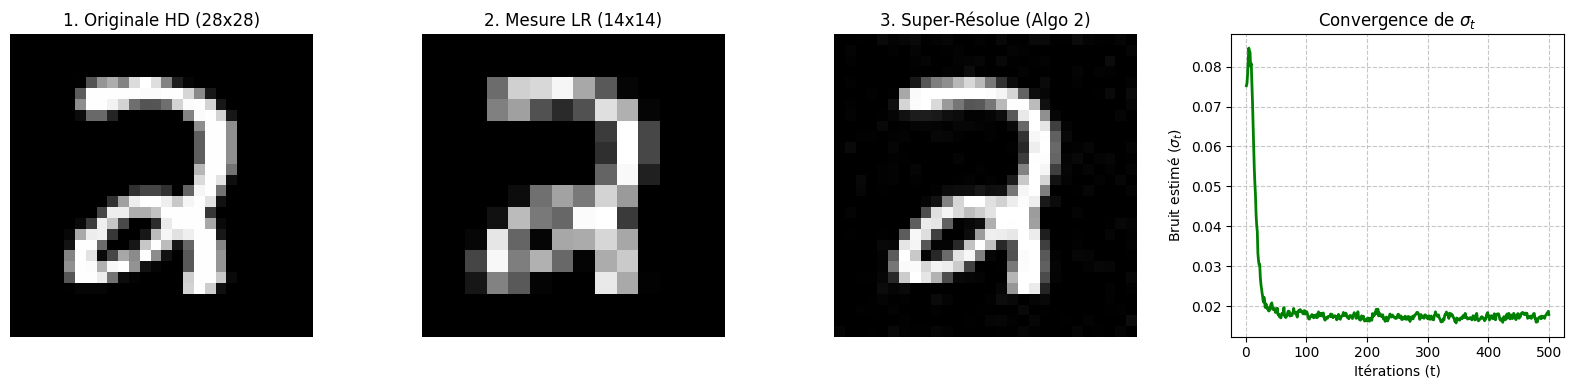

In [407]:
def super_resolution_experiment_algo2(model, loader, num_iter=500):
    model.eval()
    
    batch = next(iter(loader))
    x_orig = batch[0][0:1].to(device) 
    
    # Observation (Mesure LR 14x14)
    y_obs = downsample(x_orig)
    
    # Paramètres de l'Algorithme 2
    h0 = 0.05
    beta = 0.05
    N = x_orig.numel()
    
    # init
    y_0_etiree = F.interpolate(y_obs, scale_factor=facteur, mode='nearest')
    y = y_0_etiree.clone()
    y.requires_grad = False
    
    sigma_history = []
    
    for t in range(1, num_iter + 1):
        #meme chose 
        h_t = (h0 * t) / (1 + h0 * (t - 1))
        
        with torch.no_grad():
            x_hat = model(y)
        prior_dir = x_hat - y 
        y_reduit = downsample(y)
        erreur = y_reduit - y_obs
        
        data_gradient = 2.0 * upsample(erreur)
        
        d_t = prior_dir - data_gradient
        
        norm_sq = torch.sum(d_t**2) / N
        sigma_t = torch.sqrt(norm_sq).item()
        sigma_history.append(sigma_t)
        
        variance_factor = max((1 - beta * h_t)**2 - (1 - h_t)**2, 0.0)
        gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))
        
        noise = torch.randn_like(y) * gamma_t
        y = y + h_t * d_t + noise
        y = torch.clamp(y, 0, 1)

    plt.figure(figsize=(16, 4))
    
    plt.subplot(1, 4, 1)
    plt.imshow(x_orig.cpu().squeeze(), cmap='gray')
    plt.title("1. Originale HD (28x28)")
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    # On affiche la petite image (14x14)
    plt.imshow(y_obs.cpu().squeeze(), cmap='gray')
    plt.title(f"2. Mesure LR (14x14)")
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    img_finale = torch.clamp(y, 0, 1).cpu().squeeze().detach()
    plt.imshow(img_finale, cmap='gray')
    plt.title("3. Super-Résolue (Algo 2)")
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.plot(range(1, num_iter + 1), sigma_history, color='green', linewidth=2)
    plt.title(r"Convergence de $\sigma_t$")
    plt.xlabel("Itérations (t)")
    plt.ylabel(r"Bruit estimé ($\sigma_t$)")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Lancer l'expérience
super_resolution_experiment_algo2(model, train_loader, num_iter=500)

De même on arrive bien à resample une image

## Morphing d'images

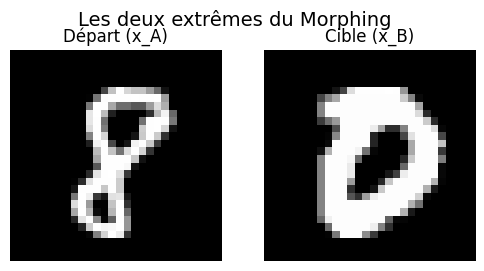

/var/folders/vm/951zcnvn12z0rcgdyj5svs0c0000gn/T/ipykernel_3567/3188657791.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))


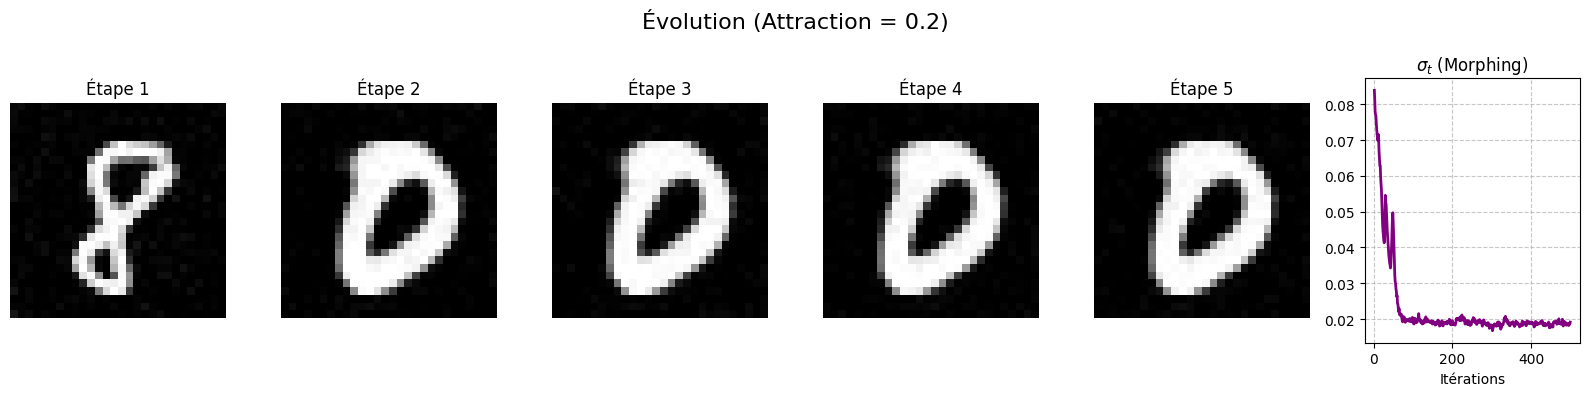

In [416]:
def morphing_experiment_algo2(model, loader, num_iter=500):

    model.eval()
    
    batch = next(iter(loader))
    x_A = batch[0][0:1].to(device) # Image de départ 
    x_B = batch[0][1:2].to(device) # Image d'arrivée (la cible)
    
    # Affichage des cibles
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(x_A.cpu().squeeze(), cmap='gray')
    plt.title("Départ (x_A)")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(x_B.cpu().squeeze(), cmap='gray')
    plt.title("Cible (x_B)")
    plt.axis('off')
    plt.suptitle("Les deux extrêmes du Morphing", fontsize=14)
    plt.show()

    # Paramètres Algo 2
    h0 = 0.05
    beta = 0.05
    N = x_A.numel()
    
    # Force d'attraction vers x_B
    lambda_attraction = 0.2

    # Initialisation
    y = x_A.clone()
    
    # Sauvegardes pour l'affichage
    etapes = []
    intervalles = [0, num_iter//4, num_iter//2, 3*num_iter//4, num_iter-1]
    sigma_history = []
    
    # Boucle d'optimisation
    for t in range(1, num_iter + 1):
        # meme
        h_t = (h0 * t) / (1 + h0 * (t - 1))
        
        with torch.no_grad():
            x_hat = model(y)
        prior_dir = x_hat - y       
        
        attraction = x_B - y        
        
        d_t = prior_dir + lambda_attraction * attraction
        
        norm_sq = torch.sum(d_t**2) / N
        sigma_t = torch.sqrt(norm_sq).item()
        sigma_history.append(sigma_t)
        
        variance_factor = max((1 - beta * h_t)**2 - (1 - h_t)**2, 0.0)
        gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))
        
        noise = torch.randn_like(y) * gamma_t
        y = y + h_t * d_t + noise
        y = torch.clamp(y, 0, 1)
        
        # Sauvegarde des frames clés
        if (t-1) in intervalles:
            etapes.append(y.clone())

    plt.figure(figsize=(16, 4))
    
    # Affichage des 5 étapes du morphing
    for i, img in enumerate(etapes):
        plt.subplot(1, 6, i+1) # 6 colonnes : 5 images + 1 plot
        plt.imshow(img.cpu().squeeze(), cmap='gray')
        plt.title(f"Étape {i+1}")
        plt.axis('off')
        
    # Affichage de la convergence de Sigma
    plt.subplot(1, 6, 6)
    plt.plot(range(1, num_iter + 1), sigma_history, color='purple', linewidth=2)
    plt.title(r"$\sigma_t$ (Morphing)")
    plt.xlabel("Itérations")
    plt.grid(True, linestyle='--', alpha=0.7)
        
    plt.suptitle(f"Évolution (Attraction = {lambda_attraction})", fontsize=16)
    plt.tight_layout()
    plt.show()

# Lancement
morphing_experiment_algo2(model, train_loader, num_iter=500)

## Génération de nouvelles images 

Je pense qu'ici on atteint globalement la limite du CNN qui a du mal à avoir vu plus global mais qui voit plus des zones de pixels localement. Je dirai que ce dernier parait assez aveugle. Le modèle va globalment imaginer des formes mais on reconnait quand même une structure.

Iter 500 | Sigma actuel : 0.0321
Iter 1000 | Sigma actuel : 0.0285
Iter 1500 | Sigma actuel : 0.0314
Iter 2000 | Sigma actuel : 0.0269
Iter 2500 | Sigma actuel : 0.0226
Iter 3000 | Sigma actuel : 0.0212
Iter 3500 | Sigma actuel : 0.0209
Iter 4000 | Sigma actuel : 0.0212
Iter 4500 | Sigma actuel : 0.0209
Iter 5000 | Sigma actuel : 0.0217
Terminé en 5000 itérations. Sigma final : 0.0217


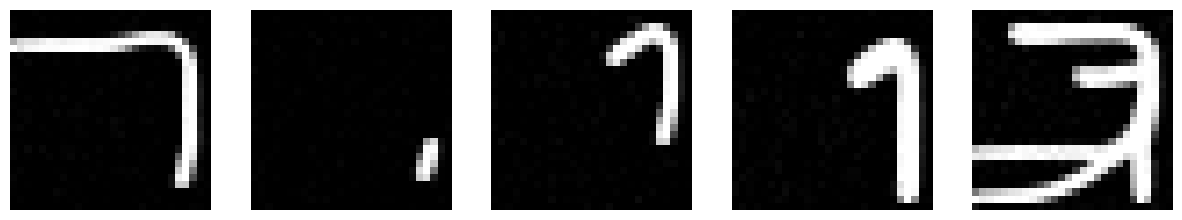

In [471]:
def algorithm_1_generation(model, num_images=5, beta=0.15, max_iter=5000):
    model.eval()
    
    sigma_L = 0.017 
    h_0 = 0.01       
    
    y = torch.rand(num_images, 1, 28, 28).to(device)
    
    sigma_t_val = 0.4
    t = 1
    
    while sigma_t_val > sigma_L and t < max_iter:
        
        h_t = (h_0 * t) / (1.0 + h_0 * (t - 1))
        
        with torch.no_grad():
            x_hat = model(y)
        d_t = x_hat - y 
        
        sigma_t_sq = torch.mean(d_t**2, dim=[1, 2, 3], keepdim=True)
        sigma_t_val = torch.sqrt(sigma_t_sq).max().item()
        
        terme_1 = (1.0 - beta * h_t)**2
        terme_2 = (1.0 - h_t)**2
        variance_factor = max(terme_1 - terme_2, 0.0)
        gamma_t = torch.sqrt(variance_factor * sigma_t_sq)
        
        z_t = torch.randn_like(y)
        y = y + h_t * d_t + gamma_t * z_t
        y = torch.clamp(y, 0, 1)
        
        t += 1
        
        if t % 500 == 0:
            print(f"Iter {t} | Sigma actuel : {sigma_t_val:.4f}")
        
    print(f"Terminé en {t} itérations. Sigma final : {sigma_t_val:.4f}")

    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        img_finale = y[i].cpu().squeeze().detach()
        plt.imshow(img_finale, cmap='gray', vmin=0, vmax=1)
        plt.axis('off')
    plt.show()

algorithm_1_generation(model, num_images=5, beta=0.01, max_iter=5000)

Ce n'est pas optimal, mais on arrive quand même à trouver des structures générales

## Utilisation d'un DDPM


In [29]:
class Diffusion:
    def __init__(self, T=500, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.T = T
        self.device = device
        
        # Schedule linéaire des betas
        self.beta = torch.linspace(beta_start, beta_end, T).to(device)
        self.alpha = 1. - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    def noise_image(self, x, t):
        # On utilise .view(-1, 1, 1, 1) pour forcer l'alignement correct des dimensions
        sqrt_alpha_bar = torch.sqrt(self.alpha_bar[t]).view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar = torch.sqrt(1 - self.alpha_bar[t]).view(-1, 1, 1, 1)
        epsilon = torch.randn_like(x)
        return sqrt_alpha_bar * x + sqrt_one_minus_alpha_bar * epsilon, epsilon

    def sample(self, model, n):
        model.eval()
        with torch.no_grad():
            # Initialisation sur le bon device (MPS, CUDA ou CPU)
            x = torch.randn((n, 1, 28, 28), device=self.device)
            
            for i in reversed(range(self.T)):
                t = (torch.ones(n, device=self.device) * i).long()
                
                # Le réseau prédit le bruit epsilon_theta
                predicted_noise = model(x, t)
                
                # --- CORRECTION DU BROADCASTING ---
                # .view(-1, 1, 1, 1) transforme [batch] en [batch, 1, 1, 1]
                # Cela permet de multiplier correctement par x [batch, 1, 28, 28]
                alpha = self.alpha[t].view(-1, 1, 1, 1)
                alpha_bar = self.alpha_bar[t].view(-1, 1, 1, 1)
                beta = self.beta[t].view(-1, 1, 1, 1)
                
                if i > 0:
                    noise = torch.randn_like(x)
                else:
                    noise = 0
                
                # Équation de reverse diffusion (Ho et al. 2020)
                # On utilise (1 - alpha) car c'est égal à beta_t
                x = (1 / torch.sqrt(alpha)) * (
                    x - ((1 - alpha) / (torch.sqrt(1 - alpha_bar))) * predicted_noise
                ) + torch.sqrt(beta) * noise
                
        return x.clamp(0, 1)

In [7]:
class SimpleUNet(nn.Module):
    def __init__(self, T=500):
        super().__init__()
        
        # 1. MLP pour le temps : rend l'embedding beaucoup plus puissant
        self.time_mlp = nn.Sequential(
            nn.Embedding(T, 128),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128)
        )
        
        # 2. Encodeur (Descente)
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU()
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 14x14
            nn.GroupNorm(8, 128),
            nn.SiLU()
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, stride=2, padding=1), # 7x7
            nn.GroupNorm(8, 256),
            nn.SiLU()
        )

        # 3. Décodeur (Remontée)
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), # 14x14
            nn.GroupNorm(8, 128),
            nn.SiLU()
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # 28x28
            nn.GroupNorm(8, 64),
            nn.SiLU()
        )
        
        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t):
        # Projection du temps
        t_emb = self.time_mlp(t)[:, :, None, None] # [batch, 128, 1, 1]
        
        # Encodeur avec injection du temps par étapes
        h1 = self.enc1(x) 
        h2 = self.enc2(h1) 
        # On injecte le temps dans la couche la plus profonde (128 canaux)
        h2 = h2 + t_emb 
        
        h3 = self.enc3(h2) # Le "bottleneck" à 256 canaux
        
        # Décodeur avec Skip Connections (très important pour la netteté)
        res1 = self.dec1(h3)
        res2 = self.dec2(res1 + h2) # Connexion avec h2 (14x14)
        
        return self.out(res2 + h1) # Connexion avec h1 (28x28)

In [30]:
from torch.utils.data import DataLoader, TensorDataset, Subset

# On s'assure d'utiliser le DATASET d'origine (train_tensor)
full_dataset = TensorDataset(train_tensor) 

subset_indices = torch.arange(25000)
# On applique le Subset sur le dataset, pas sur le loader !
train_subset = Subset(full_dataset, subset_indices)

train_loader = DataLoader(
    train_subset, 
    batch_size=1024, 
    shuffle=True, 
    num_workers=0,      # On met 0 ici pour éviter les erreurs de "multiprocessing" sur VS Code
    pin_memory=True if torch.cuda.is_available() else False
)

Utilisation du device : mps
Epoch 1/20 | Loss moyenne: 0.3477
Epoch 2/20 | Loss moyenne: 0.1280
Epoch 3/20 | Loss moyenne: 0.1000
Epoch 4/20 | Loss moyenne: 0.0793
Epoch 5/20 | Loss moyenne: 0.0675
Epoch 6/20 | Loss moyenne: 0.0613
Epoch 7/20 | Loss moyenne: 0.0567
Epoch 8/20 | Loss moyenne: 0.0539
Epoch 9/20 | Loss moyenne: 0.0522
Epoch 10/20 | Loss moyenne: 0.0493
Epoch 11/20 | Loss moyenne: 0.0481
Epoch 12/20 | Loss moyenne: 0.0462
Epoch 13/20 | Loss moyenne: 0.0447
Epoch 14/20 | Loss moyenne: 0.0436
Epoch 15/20 | Loss moyenne: 0.0432
Epoch 16/20 | Loss moyenne: 0.0406
Epoch 17/20 | Loss moyenne: 0.0398
Epoch 18/20 | Loss moyenne: 0.0394
Epoch 19/20 | Loss moyenne: 0.0380
Epoch 20/20 | Loss moyenne: 0.0372


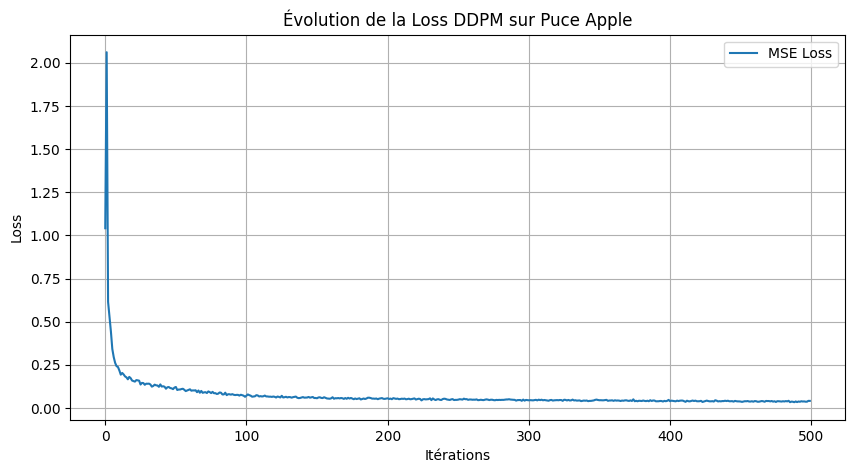

In [31]:
# 1. Sélection du device Apple (mps)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Utilisation du device : {device}")

model_ddpm = SimpleUNet().to(device)
diff = Diffusion(T=500, device=device)
optimizer = optim.Adam(model_ddpm.parameters(), lr=1e-3)
mse = nn.MSELoss()

def train_ddpm(epochs=15):
    model_ddpm.train()
    loss_history = []
    
    # Sur Apple Silicon, l'autocast mps est supporté sur les versions récentes de PyTorch
    # Sinon, on s'en passe car le MPS est déjà très performant sur MNIST
    use_amp = torch.backends.mps.is_available()

    for epoch in range(epochs):
        epoch_loss = 0
        for i, batch in enumerate(train_loader):
            # Envoi des données sur la puce Apple
            images = batch[0].to(device)
            t = torch.randint(0, diff.T, (images.shape[0],)).to(device)
            x_t, noise = diff.noise_image(images, t)
            
            optimizer.zero_grad()
            
            # Entraînement standard (le MPS gère très bien le Float32)
            pred = model_ddpm(x_t, t)
            loss = mse(pred, noise)
            
            loss.backward()
            optimizer.step()
            
            loss_history.append(loss.item())
            epoch_loss += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs} | Loss moyenne: {epoch_loss/len(train_loader):.4f}")
    
    return loss_history

# --- LANCEMENT ---
history = train_ddpm(epochs=20)

# --- AFFICHAGE DE LA LOSS ---
plt.figure(figsize=(10, 5))
plt.plot(history, label='MSE Loss')
plt.title('Évolution de la Loss DDPM sur Puce Apple')
plt.xlabel('Itérations')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()



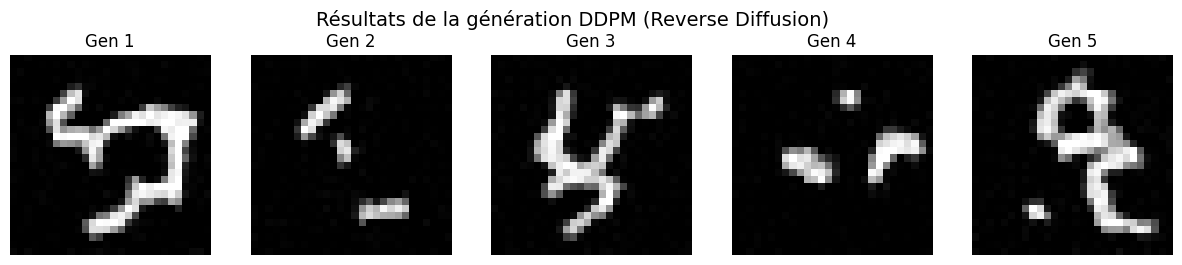

In [86]:
imgs = diff.sample(model_ddpm, n=5)

# 2. Affichage des résultats
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    
    # .detach().cpu() est crucial pour passer de la puce Apple à l'affichage
    img = imgs[i].detach().cpu().squeeze().numpy()
    
    plt.imshow(img, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
    plt.title(f"Gen {i+1}")

plt.suptitle("Résultats de la génération DDPM (Reverse Diffusion)", fontsize=14)
plt.show()

On voit les chiffres que notre modèle veut générer même si ce n'est pas parfait. 

## Comparer la restoration avec DRUNet

In [49]:
from torch.utils.data import DataLoader, TensorDataset, Subset

# On s'assure d'utiliser le DATASET d'origine (train_tensor)
full_dataset = TensorDataset(train_tensor) 

subset_indices = torch.arange(60000)
# On applique le Subset sur le dataset, pas sur le loader !
train_subset = Subset(full_dataset, subset_indices)

train_loader = DataLoader(
    train_subset, 
    batch_size=1024, 
    shuffle=True, 
    num_workers=0,      # On met 0 ici pour éviter les erreurs de "multiprocessing" sur VS Code
    pin_memory=True if torch.cuda.is_available() else False
)

In [50]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # Strictement Bias-Free
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)

    def forward(self, x):
        # La magie du résiduel : l'entrée s'additionne à la sortie
        return x + self.conv2(self.relu(self.conv1(x)))

class DRUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, nc=32):
        super().__init__()
        
        # Head
        self.head = nn.Conv2d(in_channels, nc, 3, padding=1, bias=False)

        # Encodeur (Descente)
        self.down1_res = ResBlock(nc)
        self.down1 = nn.Conv2d(nc, nc*2, 2, stride=2, bias=False) # 28x28 -> 14x14

        self.down2_res = ResBlock(nc*2)
        self.down2 = nn.Conv2d(nc*2, nc*4, 2, stride=2, bias=False) # 14x14 -> 7x7

        # Bottleneck (Le fond du U-Net)
        self.bottleneck = ResBlock(nc*4)

        # Décodeur (Remontée) avec concaténation
        self.up2 = nn.ConvTranspose2d(nc*4, nc*2, 2, stride=2, bias=False) # 7x7 -> 14x14
        # Après concaténation, on a nc*2 + nc*2 = nc*4 canaux
        self.up2_res = ResBlock(nc*4) 

        self.up1 = nn.ConvTranspose2d(nc*4, nc, 2, stride=2, bias=False) # 14x14 -> 28x28
        # Après concaténation, on a nc + nc = nc*2 canaux
        self.up1_res = ResBlock(nc*2)

        # Tail
        self.tail = nn.Conv2d(nc*2, out_channels, 3, padding=1, bias=False)

    def forward(self, x):
        # 1. Extraction initiale
        x0 = self.head(x)

        # 2. Descente
        x1 = self.down1_res(x0)
        x_down1 = self.down1(x1)

        x2 = self.down2_res(x_down1)
        x_down2 = self.down2(x2)

        # 3. Bottleneck
        x_bot = self.bottleneck(x_down2)

        # 4. Remontée 1
        x_up2 = self.up2(x_bot)
        x_up2_cat = torch.cat([x_up2, x2], dim=1) # Skip connection du U-Net
        x_up2_out = self.up2_res(x_up2_cat)

        # 5. Remontée 2
        x_up1 = self.up1(x_up2_out)
        x_up1_cat = torch.cat([x_up1, x1], dim=1) # Skip connection du U-Net
        x_up1_out = self.up1_res(x_up1_cat)

        # 6. Sortie finale
        return self.tail(x_up1_out)

Début de l'entraînement du DRUNet sur mps...
Epoch 1/20 | Loss moyenne: 0.0275
Epoch 2/20 | Loss moyenne: 0.0183
Epoch 3/20 | Loss moyenne: 0.0150
Epoch 4/20 | Loss moyenne: 0.0133
Epoch 5/20 | Loss moyenne: 0.0125
Epoch 6/20 | Loss moyenne: 0.0121
Epoch 7/20 | Loss moyenne: 0.0117
Epoch 8/20 | Loss moyenne: 0.0114
Epoch 9/20 | Loss moyenne: 0.0112
Epoch 10/20 | Loss moyenne: 0.0109
Epoch 11/20 | Loss moyenne: 0.0108
Epoch 12/20 | Loss moyenne: 0.0105
Epoch 13/20 | Loss moyenne: 0.0105
Epoch 14/20 | Loss moyenne: 0.0103
Epoch 15/20 | Loss moyenne: 0.0102
Epoch 16/20 | Loss moyenne: 0.0102
Epoch 17/20 | Loss moyenne: 0.0100
Epoch 18/20 | Loss moyenne: 0.0099
Epoch 19/20 | Loss moyenne: 0.0098
Epoch 20/20 | Loss moyenne: 0.0098


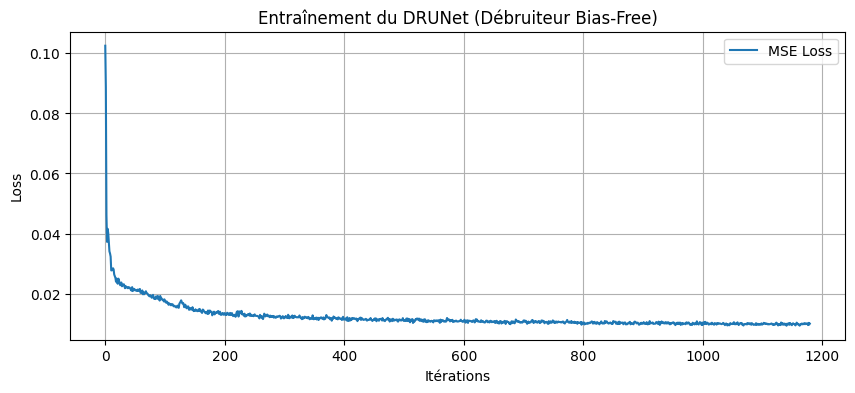

In [52]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model_drunet = DRUNet().to(device)

# Le learning rate à 1e-3 fonctionne très bien pour ce type d'architecture
optimizer_drunet = torch.optim.Adam(model_drunet.parameters(), lr=1e-3)
mse = nn.MSELoss()

def train_drunet(epochs=30):
    model_drunet.train()
    loss_history = []
    
    print(f"Début de l'entraînement du DRUNet sur {device}...")
    
    for epoch in range(epochs):
        epoch_loss = 0
        for batch in train_loader: # On utilise ton train_loader optimisé avec le Subset
            # 1. Les images propres (x)
            clean_images = batch[0].to(device)
            
            # 2. Création d'un bruit aléatoire pour chaque image
            # On génère des sigma aléatoires entre 0.0 et 1.0
            sigma = torch.rand(clean_images.shape[0], 1, 1, 1, device=device)
            
            # On crée le bruit gaussien et on le multiplie par sigma
            noise = torch.randn_like(clean_images) * sigma
            
            # L'image que le réseau va voir (y)
            noisy_images = clean_images + noise
            
            # 3. Prédiction : le réseau doit retrouver l'image propre
            optimizer_drunet.zero_grad()
            pred_clean = model_drunet(noisy_images)
            
            # 4. Calcul de l'erreur et mise à jour
            loss = mse(pred_clean, clean_images)
            loss.backward()
            optimizer_drunet.step()
            
            epoch_loss += loss.item()
            loss_history.append(loss.item())
            
        print(f"Epoch {epoch+1}/{epochs} | Loss moyenne: {epoch_loss/len(train_loader):.4f}")
        
    return loss_history

# --- LANCEMENT ---
history_drunet = train_drunet(epochs=20) # 20 époques suffisent pour voir de gros résultats

# --- AFFICHAGE DE LA LOSS ---
plt.figure(figsize=(10, 4))
plt.plot(history_drunet, label='MSE Loss')
plt.title('Entraînement du DRUNet (Débruiteur Bias-Free)')
plt.xlabel('Itérations')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

/var/folders/vm/951zcnvn12z0rcgdyj5svs0c0000gn/T/ipykernel_77696/2606790029.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))


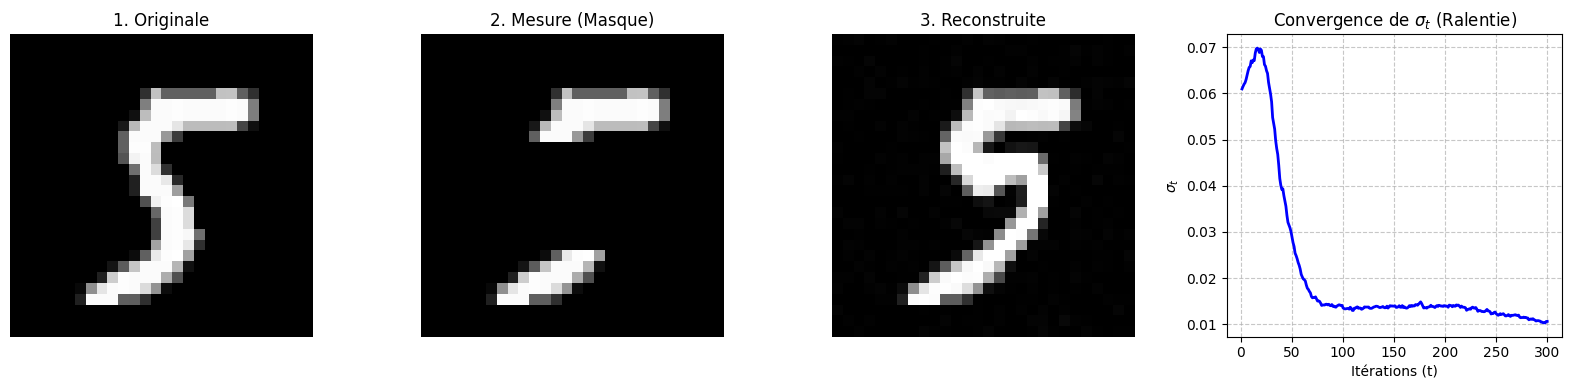

In [64]:
def inpainting_experiment_algo2(model, loader, num_iter=3000): # On monte num_iter car on va plus lentement
    '''Fait de l'inpainting en respectant strictement l'Algorithme 2 du papier, avec un cooling plus doux'''

    model.eval() 
    
    batch = next(iter(loader))
    x_orig = batch[0][0:1].to(device) 
    
    # Masque (Exp 1 : Mettre un carré noir au milieu)
    mask = torch.ones_like(x_orig)
    mask[:, :, 10:20, 10:20] = 0 
    
    x_mesure = x_orig * mask 
    
    # --- MODIFICATIONS CLÉS ICI ---
    h0 = 0.005  # Divisé par 10 (était 0.05). La pente sera beaucoup plus douce.
    beta = 0.15 # Augmenté légèrement (était 0.1) pour forcer l'exploration.
    # ------------------------------
    
    N = x_orig.numel() 
    
    # On initialise l'espace manquant avec un bruit fort (moyenne 0.5, std 0.5)
    # C'est important pour que la dynamique ait de l'énergie au départ.
    y = x_mesure + (torch.randn_like(x_orig) * 0.5 + 0.5) * (1 - mask)
    y = torch.clamp(y, 0, 1) # On s'assure de démarrer dans [0, 1]
    
    sigma_history = []
    
    for t in range(1, num_iter + 1):
        # La courbe de h_t montera beaucoup plus lentement grâce au petit h0
        h_t = (h0 * t) / (1 + h0 * (t - 1))
        
        with torch.no_grad():
            x_hat = model(y)
        f_y = x_hat - y 
        
        # d_t : On fait confiance au débruiteur sur les pixels manquants, 
        # et on force le retour à la mesure sur les pixels connus.
        d_t = (1 - mask) * f_y + mask * (x_mesure - y)
        
        # Estimation de sigma_t^2
        norm_sq = torch.sum(d_t**2) / N
        sigma_t = torch.sqrt(norm_sq).item()
        sigma_history.append(sigma_t)
        
        variance_factor = max((1 - beta * h_t)**2 - (1 - h_t)**2, 0.0) 
        gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))
        
        noise = torch.randn_like(y) * gamma_t
        y = y + h_t * d_t + noise
        y = torch.clamp(y, 0, 1)

    # --- AFFICHAGE --- (Identique au tien)
    plt.figure(figsize=(16, 4))
    
    plt.subplot(1, 4, 1)
    plt.imshow(x_orig.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title("1. Originale")
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(x_mesure.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title("2. Mesure (Masque)")
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    img_finale = y.cpu().squeeze()
    plt.imshow(img_finale, cmap='gray', vmin=0, vmax=1)
    plt.title("3. Reconstruite")
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.plot(range(1, num_iter + 1), sigma_history, color='blue', linewidth=2)
    plt.title(r"Convergence de $\sigma_t$ (Ralentie)")
    plt.xlabel("Itérations (t)")
    plt.ylabel(r"$\sigma_t$")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Lancement (On met 3000 itérations car la descente est plus lente)
inpainting_experiment_algo2(model_drunet, train_loader, num_iter=300)

/var/folders/vm/951zcnvn12z0rcgdyj5svs0c0000gn/T/ipykernel_77696/187385652.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))


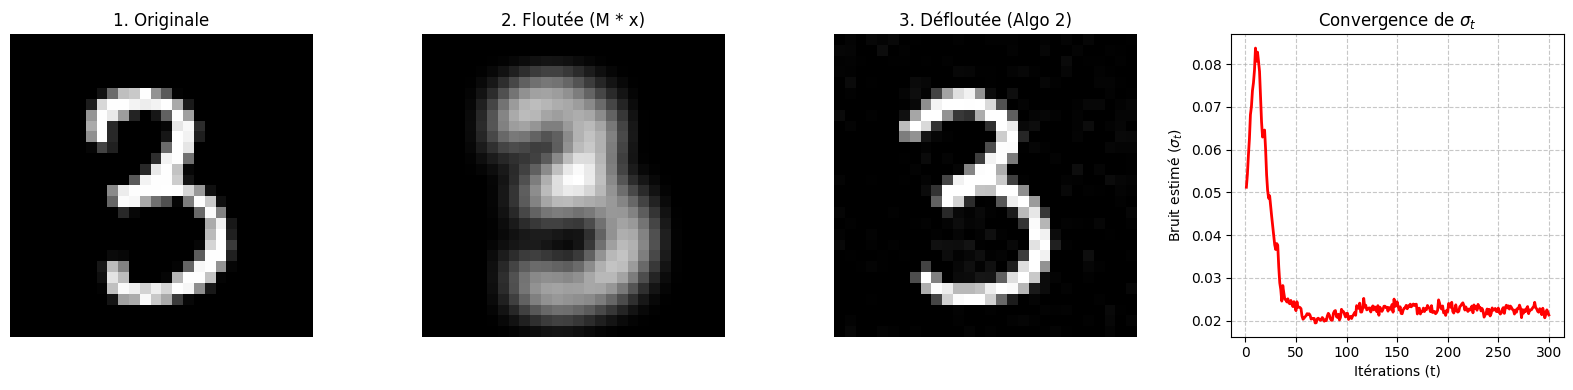

In [70]:
def deblur_experiment_algo2(model, loader, num_iter=900):

    model.eval() # mode évaluation
    
    batch = next(iter(loader))
    x_orig = batch[0][0:1].to(device) # Image propre
    
    # Création de l'observation
    y_obs = blur(x_orig)
    
    # Paramètres de l'Algorithme 2
    h0 = 0.05
    beta = 0.01
    N = x_orig.numel()
    
    # Initialisation
    y = y_obs.clone()
    y.requires_grad = False
    
    sigma_history = []
    
    for t in range(1, num_iter + 1):
        # h
        h_t = (h0 * t) / (1 + h0 * (t - 1))
        
        # grad
        with torch.no_grad():
            x_hat = model(y)
        f_y = x_hat - y 
        
        erreur = blur(y) - y_obs
        data_gradient = blur_transpose(erreur)
        
        d_t = f_y - 2.0 * data_gradient
        
        # bruit
        norm_sq = torch.sum(d_t**2) / N
        sigma_t = torch.sqrt(norm_sq).item()
        sigma_history.append(sigma_t)
        
        # amplitude
        variance_factor = max((1 - beta * h_t)**2 - (1 - h_t)**2, 0.0)
        gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))
        
        # Itération (injection de bruit et montée de gradient)
        noise = torch.randn_like(y) * gamma_t
        y = y + h_t * d_t + noise
        y = torch.clamp(y, 0, 1)

    # ==========================
    # AFFICHAGE DES RÉSULTATS
    # ==========================
    plt.figure(figsize=(16, 4))
    
    plt.subplot(1, 4, 1)
    plt.imshow(x_orig.cpu().squeeze(), cmap='gray')
    plt.title("1. Originale")
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(y_obs.cpu().squeeze(), cmap='gray')
    plt.title("2. Floutée (M * x)")
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    img_finale = torch.clamp(y, 0, 1).cpu().squeeze().detach()
    plt.imshow(img_finale, cmap='gray')
    plt.title("3. Défloutée (Algo 2)")
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.plot(range(1, num_iter + 1), sigma_history, color='red', linewidth=2)
    plt.title(r"Convergence de $\sigma_t$")
    plt.xlabel("Itérations (t)")
    plt.ylabel(r"Bruit estimé ($\sigma_t$)")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Lancer l'expérience
deblur_experiment_algo2(model_drunet, train_loader, num_iter=300)

/var/folders/vm/951zcnvn12z0rcgdyj5svs0c0000gn/T/ipykernel_77696/168226587.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))


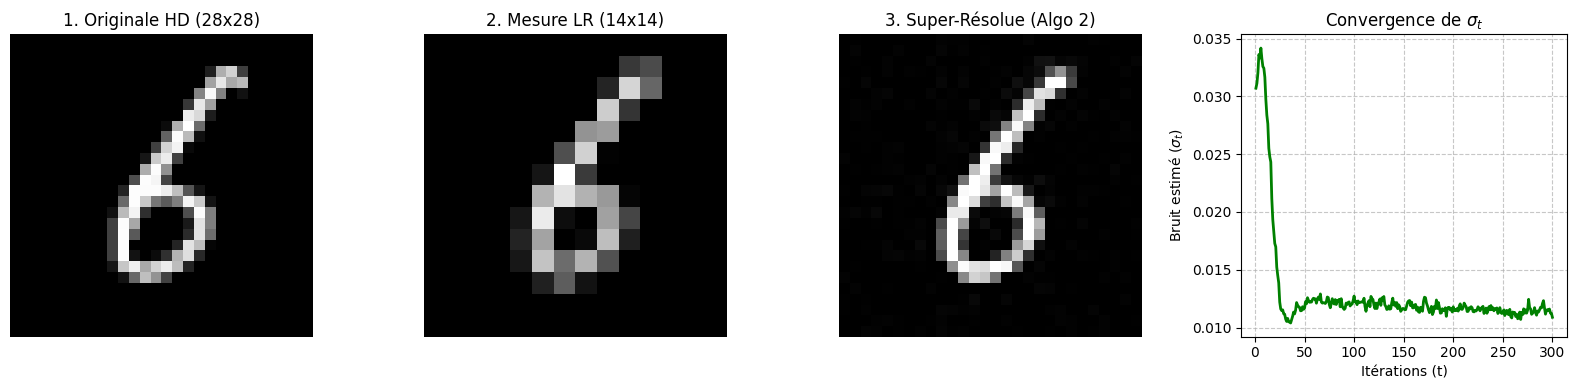

In [75]:
def super_resolution_experiment_algo2(model, loader, num_iter=500):
    model.eval()
    
    batch = next(iter(loader))
    x_orig = batch[0][0:1].to(device) 
    
    # Observation (Mesure LR 14x14)
    y_obs = downsample(x_orig)
    
    # Paramètres de l'Algorithme 2
    h0 = 0.05
    beta = 0.05
    N = x_orig.numel()
    
    # init
    y_0_etiree = F.interpolate(y_obs, scale_factor=facteur, mode='nearest')
    y = y_0_etiree.clone()
    y.requires_grad = False
    
    sigma_history = []
    
    for t in range(1, num_iter + 1):
        #meme chose 
        h_t = (h0 * t) / (1 + h0 * (t - 1))
        
        with torch.no_grad():
            x_hat = model(y)
        prior_dir = x_hat - y 
        y_reduit = downsample(y)
        erreur = y_reduit - y_obs
        
        data_gradient = 2.0 * upsample(erreur)
        
        d_t = prior_dir - data_gradient
        
        norm_sq = torch.sum(d_t**2) / N
        sigma_t = torch.sqrt(norm_sq).item()
        sigma_history.append(sigma_t)
        
        variance_factor = max((1 - beta * h_t)**2 - (1 - h_t)**2, 0.0)
        gamma_t = torch.sqrt(torch.tensor(variance_factor * norm_sq, device=device))
        
        noise = torch.randn_like(y) * gamma_t
        y = y + h_t * d_t + noise
        y = torch.clamp(y, 0, 1)

    plt.figure(figsize=(16, 4))
    
    plt.subplot(1, 4, 1)
    plt.imshow(x_orig.cpu().squeeze(), cmap='gray')
    plt.title("1. Originale HD (28x28)")
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    # On affiche la petite image (14x14)
    plt.imshow(y_obs.cpu().squeeze(), cmap='gray')
    plt.title(f"2. Mesure LR (14x14)")
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    img_finale = torch.clamp(y, 0, 1).cpu().squeeze().detach()
    plt.imshow(img_finale, cmap='gray')
    plt.title("3. Super-Résolue (Algo 2)")
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.plot(range(1, num_iter + 1), sigma_history, color='green', linewidth=2)
    plt.title(r"Convergence de $\sigma_t$")
    plt.xlabel("Itérations (t)")
    plt.ylabel(r"Bruit estimé ($\sigma_t$)")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Lancer l'expérience
super_resolution_experiment_algo2(model_drunet, train_loader, num_iter=300)